In [1]:
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

from src.config import PLOTS_DIR
from src.matplotlib import Color, Styles
from src.service import ExperimentService

plt.style.use(Styles.CMR10.value)
experiment_service = ExperimentService()

2025-11-25 18:40:57.189 | INFO     | src.config:<module>:28 - Loaded environment variables from /home/iragca/Documents/github/capstone-project-2/.env
2025-11-25 18:40:57.190 | INFO     | src.config:<module>:67 - PROJECT_ROOT: /home/iragca/Documents/github/capstone-project-2
2025-11-25 18:40:57.190 | INFO     | src.config:<module>:68 - DATA_DIR: /home/iragca/Documents/github/capstone-project-2/data
2025-11-25 18:40:57.193 | INFO     | src.matplotlib.color:<module>:104 - Accessible color palette inspired by https://github.com/mpetroff/accessible-color-cycles.


In [6]:
def resolve_name(name: str) -> str:
    exceptions = ["Loss", "duration (sec)", "system/gpu_0_memory_usage_megabytes"]

    return f"TEST: {name}" if name not in exceptions else name


def plot_hyperparameter(
    metric: str,
    hyperparam: str,
    df: pl.DataFrame,
    history: pl.DataFrame,
    subtitle: str = None,
    save: bool = False,
):
    metric_name = resolve_name(metric)
    sns.lineplot(
        data=(
            df.select(["run_id", hyperparam])
            .join(
                history.filter(pl.col("metric") == metric_name),
                on="run_id",
            )
            .to_pandas()
        ),
        x="step",
        y="value",
        hue=hyperparam,
    )

    if subtitle:
        title = f"Test {metric} over Epochs: {subtitle}"
    else:
        title = f"Test {metric} over Epochs"
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(f"Test {metric}")
    plt.legend(title=hyperparam.title())

    if save:
        plt.savefig(
            PLOTS_DIR / f"{metric}_{hyperparam}_directed_vs_undirected.png",
            dpi=300,
            format="png",
            bbox_inches="tight",
        )


def plot_metric_over_epochs(metric: str, history: pl.DataFrame):
    metric_name = resolve_name(metric)

    sns.lineplot(
        data=history.filter(pl.col("metric") == metric_name).to_pandas(),
        x="step",
        y="value",
    )
    plt.title(f"{metric} over Epochs for Dir vs Undir Experiment (50 Trials)")
    plt.xlabel("Epochs")
    plt.ylabel(metric.title())

## Hidden Size

In [3]:
hidden_size_df = experiment_service.get_experiment_runs_as_df(experiment_name="Hidden Size")
hidden_size_df

run_id,duration (sec),system/gpu_0_memory_usage_megabytes,Loss,TEST: Accuracy,TEST: ROC-AUC,TEST: PR-AUC,TEST: Precision,TEST: Recall,TEST: F1 Score,TRAIN: Accuracy,TRAIN: ROC-AUC,TRAIN: PR-AUC,TRAIN: Precision,TRAIN: Recall,TRAIN: F1 Score,VAL: Accuracy,VAL: ROC-AUC,VAL: PR-AUC,VAL: Precision,VAL: Recall,VAL: F1 Score,epochs,hidden_dim,threshold,device,num_layers,homogeneous,directed,graphsage,agg_method
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,str,i64,bool,bool,bool,str
"""d88625e1c989491281b6e399f09ddb…",417.712,2377.8,0.598835,0.733572,0.959123,0.925556,0.652377,1.0,0.789622,0.696457,0.869684,0.771419,0.622245,1.0,0.76714,0.713146,0.934227,0.878024,0.635442,1.0,0.777089,500,256,0.5,"""cuda""",8,true,true,true,null
"""575bd270792e4c1bb679d73f3cda46…",418.169,2386.6,0.634316,0.507974,0.952024,0.915371,0.504019,1.0,0.670229,0.505338,0.871593,0.782513,0.502685,0.999515,0.66894,0.507976,0.92979,0.874894,0.50402,1.0,0.67023,500,256,0.5,"""cuda""",8,true,true,true,null
"""443dba6a1add4c1a9a3b2bd1ce8651…",417.046,2364.9,0.607085,0.518284,0.946155,0.91193,0.509312,1.0,0.674893,0.509301,0.870335,0.790085,0.504694,1.0,0.670826,0.516502,0.922318,0.872123,0.508389,1.0,0.674082,500,256,0.5,"""cuda""",8,true,true,true,null
"""ccef8ddc6c8e4a5fbeba7e36871fcf…",425.188,2564.3,0.604208,0.674182,0.956349,0.923536,0.60546,1.0,0.754251,0.655856,0.87586,0.781225,0.592316,1.0,0.743968,0.683168,0.939301,0.890565,0.612121,1.0,0.759398,500,256,0.5,"""cuda""",8,true,true,true,null
"""321e56a36e3a48e3b608d56f76e8a3…",424.242,2518.9,0.603987,0.599808,0.954751,0.911812,0.555437,1.0,0.714188,0.574571,0.877189,0.779174,0.54029,1.0,0.701543,0.587459,0.938545,0.884256,0.54792,1.0,0.707944,500,256,0.5,"""cuda""",8,true,true,true,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""80a10e26b36040c3a563fe4fe08aab…",51.759,883.8,0.602361,0.887957,0.95737,0.923382,0.816936,1.0,0.899246,0.817535,0.883292,0.792425,0.732638,1.0,0.845691,0.874312,0.946928,0.903244,0.799121,1.0,0.888346,500,2,0.5,"""cuda""",8,true,true,true,null
"""ad9ecb71ca80493eaa68fc66ee52b0…",52.884,904.8,0.613192,0.882321,0.887673,0.789847,0.809481,1.0,0.894711,0.821093,0.828091,0.731319,0.736478,1.0,0.848244,0.876238,0.883812,0.793525,0.801587,1.0,0.889868,500,2,0.5,"""cuda""",8,true,true,true,null
"""b3f13c9a03994ddcac059d0728e35b…",53.095,987.1,0.615982,0.890569,0.894732,0.845518,0.820438,1.0,0.901363,0.814704,0.81824,0.737324,0.729612,1.0,0.843671,0.874037,0.877712,0.819079,0.79877,1.0,0.888129,500,2,0.5,"""cuda""",8,true,true,true,null


In [12]:
hidden_size_df.with_columns([pl.col("hidden_dim").cast(pl.Utf8).cast(pl.Categorical())])

run_id,duration (sec),system/gpu_0_memory_usage_megabytes,Loss,TEST: Accuracy,TEST: ROC-AUC,TEST: PR-AUC,TEST: Precision,TEST: Recall,TEST: F1 Score,TRAIN: Accuracy,TRAIN: ROC-AUC,TRAIN: PR-AUC,TRAIN: Precision,TRAIN: Recall,TRAIN: F1 Score,VAL: Accuracy,VAL: ROC-AUC,VAL: PR-AUC,VAL: Precision,VAL: Recall,VAL: F1 Score,epochs,hidden_dim,threshold,device,num_layers,homogeneous,directed,graphsage,agg_method
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,cat,f64,str,i64,bool,bool,bool,str
"""d88625e1c989491281b6e399f09ddb…",417.712,2377.8,0.598835,0.733572,0.959123,0.925556,0.652377,1.0,0.789622,0.696457,0.869684,0.771419,0.622245,1.0,0.76714,0.713146,0.934227,0.878024,0.635442,1.0,0.777089,500,"""256""",0.5,"""cuda""",8,true,true,true,null
"""575bd270792e4c1bb679d73f3cda46…",418.169,2386.6,0.634316,0.507974,0.952024,0.915371,0.504019,1.0,0.670229,0.505338,0.871593,0.782513,0.502685,0.999515,0.66894,0.507976,0.92979,0.874894,0.50402,1.0,0.67023,500,"""256""",0.5,"""cuda""",8,true,true,true,null
"""443dba6a1add4c1a9a3b2bd1ce8651…",417.046,2364.9,0.607085,0.518284,0.946155,0.91193,0.509312,1.0,0.674893,0.509301,0.870335,0.790085,0.504694,1.0,0.670826,0.516502,0.922318,0.872123,0.508389,1.0,0.674082,500,"""256""",0.5,"""cuda""",8,true,true,true,null
"""ccef8ddc6c8e4a5fbeba7e36871fcf…",425.188,2564.3,0.604208,0.674182,0.956349,0.923536,0.60546,1.0,0.754251,0.655856,0.87586,0.781225,0.592316,1.0,0.743968,0.683168,0.939301,0.890565,0.612121,1.0,0.759398,500,"""256""",0.5,"""cuda""",8,true,true,true,null
"""321e56a36e3a48e3b608d56f76e8a3…",424.242,2518.9,0.603987,0.599808,0.954751,0.911812,0.555437,1.0,0.714188,0.574571,0.877189,0.779174,0.54029,1.0,0.701543,0.587459,0.938545,0.884256,0.54792,1.0,0.707944,500,"""256""",0.5,"""cuda""",8,true,true,true,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""80a10e26b36040c3a563fe4fe08aab…",51.759,883.8,0.602361,0.887957,0.95737,0.923382,0.816936,1.0,0.899246,0.817535,0.883292,0.792425,0.732638,1.0,0.845691,0.874312,0.946928,0.903244,0.799121,1.0,0.888346,500,"""2""",0.5,"""cuda""",8,true,true,true,null
"""ad9ecb71ca80493eaa68fc66ee52b0…",52.884,904.8,0.613192,0.882321,0.887673,0.789847,0.809481,1.0,0.894711,0.821093,0.828091,0.731319,0.736478,1.0,0.848244,0.876238,0.883812,0.793525,0.801587,1.0,0.889868,500,"""2""",0.5,"""cuda""",8,true,true,true,null
"""b3f13c9a03994ddcac059d0728e35b…",53.095,987.1,0.615982,0.890569,0.894732,0.845518,0.820438,1.0,0.901363,0.814704,0.81824,0.737324,0.729612,1.0,0.843671,0.874037,0.877712,0.819079,0.79877,1.0,0.888129,500,"""2""",0.5,"""cuda""",8,true,true,true,null


In [5]:
overall_history = experiment_service.all_runs_history(experiment_name="Hidden Size")
overall_history

Fetching Run Histories: 100%|██████████| 450/450 [04:06<00:00,  1.83run/s]


run_id,timestamp,step,metric,value
str,i64,i64,str,f64
"""d88625e1c989491281b6e399f09ddb…",1758968511896,0,"""system/gpu_0_memory_usage_mega…",637.9
"""d88625e1c989491281b6e399f09ddb…",1758968521920,1,"""system/gpu_0_memory_usage_mega…",2438.3
"""d88625e1c989491281b6e399f09ddb…",1758968531942,2,"""system/gpu_0_memory_usage_mega…",2407.9
"""d88625e1c989491281b6e399f09ddb…",1758968541967,3,"""system/gpu_0_memory_usage_mega…",2430.2
"""d88625e1c989491281b6e399f09ddb…",1758968551990,4,"""system/gpu_0_memory_usage_mega…",2438.7
…,…,…,…,…
"""06416dffed61404ebc64ac6ca5fde5…",1758851835849,496,"""VAL: F1 Score""",0.887695
"""06416dffed61404ebc64ac6ca5fde5…",1758851835943,497,"""VAL: F1 Score""",0.887695
"""06416dffed61404ebc64ac6ca5fde5…",1758851836037,498,"""VAL: F1 Score""",0.887695


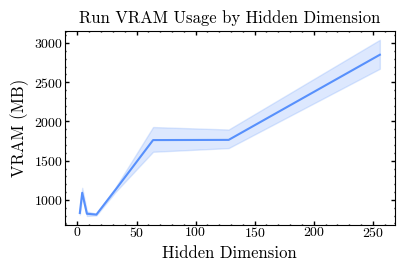

In [26]:
sns.lineplot(
    data=hidden_size_df.to_pandas(),
    x="hidden_dim",
    y="system/gpu_0_memory_usage_megabytes",
)   
plt.xlabel("Hidden Dimension")
plt.ylabel("VRAM (MB)")
plt.title("Run VRAM Usage by Hidden Dimension")
plt.savefig(
    PLOTS_DIR / "VRAM_USAGE_Hidden_Dimension.png",
    dpi=300,
    format="png",
    bbox_inches="tight",
)

Text(0, 0.5, 'VRAM (MB)')

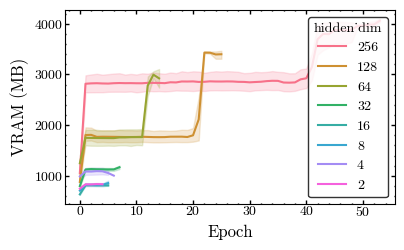

In [15]:
ax = sns.lineplot(
    data=(
        hidden_size_df.with_columns(
            [pl.col("hidden_dim").cast(pl.Utf8).cast(pl.Categorical())]
        )
        .select(["run_id", "hidden_dim"])
        .join(
            overall_history.filter(pl.col("metric") == "system/gpu_0_memory_usage_megabytes"),
            on="run_id",
        )
        .to_pandas()
    ),
    x="step",
    y="value",
    hue="hidden_dim",
)


plt.xlabel("Epoch")
plt.ylabel("VRAM (MB)")
# plt.title("Test PR-AUC over Epochs by Hidden Dimension")
# plt.legend(title="Hidden Dimension", ncol=2)
# plt.savefig(
#     PLOTS_DIR / "PR-AUC_hidden_dim_over_epochs.png",
#     dpi=300,
#     format="png",
#     bbox_inches="tight",
# )

<Axes: xlabel='step', ylabel='value'>

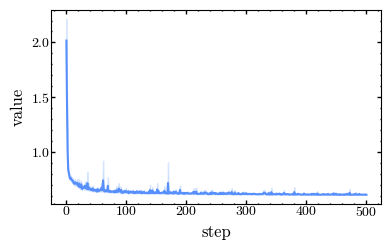

In [5]:
sns.lineplot(
    data=overall_history.filter(pl.col("metric") == "Loss").to_pandas(),
    x="step",
    y="value",
)

<Axes: xlabel='step', ylabel='value'>

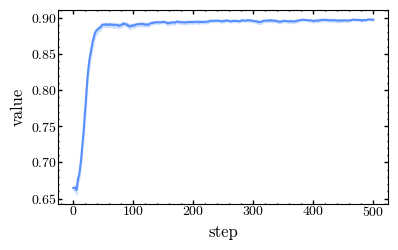

In [7]:
sns.lineplot(
    data=overall_history.filter(pl.col("metric") == "TEST: F1 Score").to_pandas(),
    x="step",
    y="value",
)

Text(0.5, 1.0, 'Mean Test ROC-AUC by Hidden Dimension')

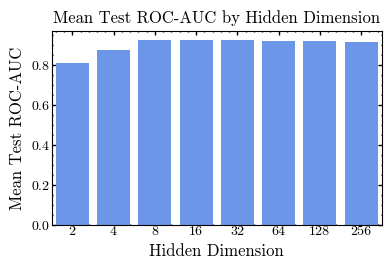

In [7]:
sns.barplot(
    data=hidden_size_df.group_by("hidden_dim").agg(pl.col("TEST: PR-AUC").mean()).to_pandas(),
    x="hidden_dim",
    y="TEST: PR-AUC",
)
plt.xlabel("Hidden Dimension")
plt.ylabel("Mean Test ROC-AUC")
plt.title("Mean Test ROC-AUC by Hidden Dimension")

In [26]:
temp_df = (
    hidden_size_df.with_columns(
        [pl.col("hidden_dim").cast(pl.Utf8).cast(pl.Categorical())]
    )
    .select(["run_id", "hidden_dim"])
    .join(
        overall_history.filter(pl.col("metric") == "TEST: PR-AUC"),
        on="run_id",
    )
    .to_pandas()
)

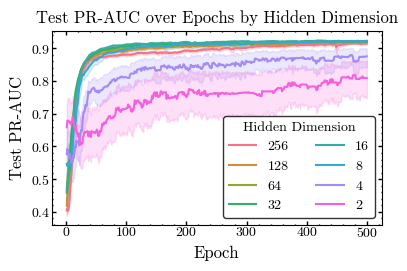

In [31]:
ax = sns.lineplot(
    data=temp_df,
    x="step",
    y="value",
    hue="hidden_dim",
)


plt.xlabel("Epoch")
plt.ylabel("Test PR-AUC")
plt.title("Test PR-AUC over Epochs by Hidden Dimension")
plt.legend(title="Hidden Dimension", ncol=2)
plt.savefig(
    PLOTS_DIR / "PR-AUC_hidden_dim_over_epochs.png",
    dpi=300,
    format="png",
    bbox_inches="tight",
)

In [ ]:
ax = sns.lineplot(
    data=temp_df,
    x="step",
    y="value",
    hue="hidden_dim",
)


plt.xlabel("Epoch")
plt.ylabel("Test PR-AUC")
plt.title("Test PR-AUC over Epochs by Hidden Dimension")
plt.legend(title="Hidden Dimension", ncol=2)
plt.savefig(
    PLOTS_DIR / "PR-AUC_hidden_dim_over_epochs.png",
    dpi=300,
    format="png",
    bbox_inches="tight",
)

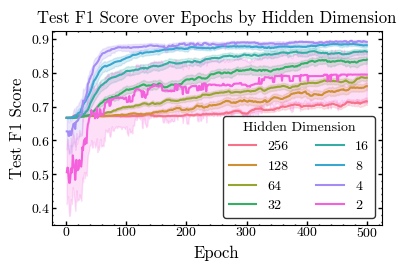

In [25]:
ax = sns.lineplot(
    data=(
        hidden_size_df.with_columns(
            [pl.col("hidden_dim").cast(pl.Utf8).cast(pl.Categorical())]
        )
        .select(["run_id", "hidden_dim"])
        .join(
            overall_history.filter(pl.col("metric") == "TEST: F1 Score"),
            on="run_id",
        )
        .to_pandas()
    ),
    x="step",
    y="value",
    hue="hidden_dim",
)


plt.xlabel("Epoch")
plt.ylabel("Test F1 Score")
plt.title("Test F1 Score over Epochs by Hidden Dimension")
plt.legend(title="Hidden Dimension", ncol=2)
plt.savefig(
    PLOTS_DIR / "F1-Score_hidden_dim_over_epochs.png",
    dpi=300,
    format="png",
    bbox_inches="tight",
)

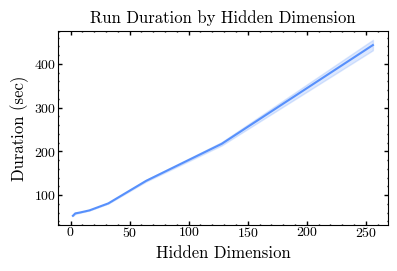

In [39]:
sns.lineplot(
    data=hidden_size_df.to_pandas(),
    x="hidden_dim",
    y="duration (sec)",
)
plt.xlabel("Hidden Dimension")
plt.ylabel("Duration (sec)")
plt.title("Run Duration by Hidden Dimension")
plt.savefig(
    PLOTS_DIR / "Duration_Hidden_Dimension.png",
    dpi=300,
    format="png",
    bbox_inches="tight",
    transparent=True,
)   

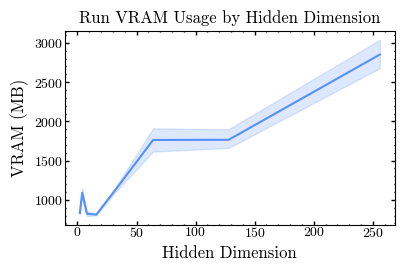

In [5]:
sns.lineplot(
    data=hidden_size_df.to_pandas(),
    x="hidden_dim",
    y="vram (mb)",
)
plt.xlabel("Hidden Dimension")
plt.ylabel("VRAM (MB)")
plt.title("Run VRAM Usage by Hidden Dimension")
plt.savefig(
    PLOTS_DIR / "VRAM_USAGE_Hidden_Dimension.png",
    dpi=300,
    format="png",
    bbox_inches="tight",
    transparent=True,
)   

In [11]:
hidden_size_df["hidden_dim"].unique()

hidden_dim
i64
2
4
8
16
32
64
128
256


## Directed vs Undirected

In [17]:
dir_vs_undir_df = experiment_service.get_experiment_runs_as_df(experiment_name="Dir vs Undir")
dir_vs_undir_df

run_id,duration (sec),system/gpu_0_memory_usage_megabytes,Loss,TEST: Accuracy,TEST: ROC-AUC,TEST: PR-AUC,TEST: Precision,TEST: Recall,TEST: F1 Score,TRAIN: Accuracy,TRAIN: ROC-AUC,TRAIN: PR-AUC,TRAIN: Precision,TRAIN: Recall,TRAIN: F1 Score,VAL: Accuracy,VAL: ROC-AUC,VAL: PR-AUC,VAL: Precision,VAL: Recall,VAL: F1 Score,epochs,hidden_dim,threshold,device,num_layers,homogeneous,directed,graphsage,agg_method
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,str,i64,bool,bool,bool,str
"""8401086e0b094cb39fadefb8d795bc…",72.508,1035.9,0.600837,0.888644,0.958774,0.926778,0.817855,1.0,0.899802,0.822064,0.877175,0.776814,0.737533,1.0,0.848943,0.878988,0.944309,0.897223,0.805137,1.0,0.892051,500,24,0.5,"""cuda""",8,true,true,true,null
"""d5a201fbda3c4db9bd8aad235d335a…",72.616,1071.9,0.603964,0.886857,0.957734,0.926358,0.815471,1.0,0.898357,0.819233,0.87635,0.785362,0.734466,1.0,0.846907,0.867162,0.936341,0.885874,0.790091,1.0,0.882739,500,24,0.5,"""cuda""",8,true,true,true,null
"""6c6e7d6f3f3b4453af03a8712a9556…",72.729,1048.6,0.601327,0.890982,0.957767,0.925024,0.820993,1.0,0.901698,0.816888,0.877063,0.77402,0.731944,1.0,0.845228,0.872662,0.947616,0.90825,0.797019,1.0,0.887046,500,24,0.5,"""cuda""",8,true,true,true,null
"""561d100ded7d4cdf94ffab837c2748…",72.562,1061.2,0.601665,0.889469,0.956583,0.927326,0.819247,0.99945,0.900421,0.818424,0.877573,0.782196,0.733816,0.999353,0.846243,0.872662,0.944811,0.90823,0.79728,0.99945,0.88699,500,24,0.5,"""cuda""",8,true,true,true,null
"""18f94038db82432daa4acd6ff01b9f…",72.96,850.2,0.59965,0.891394,0.95867,0.922868,0.82155,1.0,0.902034,0.821013,0.876919,0.786928,0.736391,1.0,0.848185,0.876788,0.940474,0.88591,0.802295,1.0,0.890304,500,24,0.5,"""cuda""",8,true,true,true,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""738efbb9d5a44055b591cdb4889dee…",88.378,1109.6,0.568283,0.863143,0.972719,0.967193,0.790115,0.989002,0.878442,0.786639,0.903948,0.862958,0.703444,0.991103,0.822858,0.852723,0.963879,0.951321,0.775038,0.993949,0.870948,500,24,0.5,"""cuda""",8,true,false,true,null
"""265b717922cb43b8acc9d3d016d043…",90.438,1104.5,0.563621,0.800385,0.973763,0.967127,0.715186,0.99835,0.833372,0.743489,0.912467,0.87033,0.661101,0.999191,0.795723,0.785754,0.963431,0.949549,0.700193,0.99945,0.823476,500,24,0.5,"""cuda""",8,true,false,true,null
"""c133506e79c849e68edd4aa594ff5a…",88.876,1130.3,0.56118,0.870085,0.953764,0.956012,0.815814,0.956008,0.880365,0.803017,0.894247,0.86192,0.729748,0.962472,0.830107,0.85011,0.938249,0.937332,0.791038,0.951595,0.86392,500,24,0.5,"""cuda""",8,true,false,true,null


In [18]:
overall_history_dir_vs_undir = experiment_service.all_runs_history(experiment_name="Dir vs Undir")
overall_history_dir_vs_undir

Fetching Run Histories: 100%|██████████| 100/100 [00:47<00:00,  2.09run/s]


run_id,timestamp,step,metric,value
str,i64,i64,str,f64
"""8401086e0b094cb39fadefb8d795bc…",1758776880683,0,"""system/gpu_0_memory_usage_mega…",823.9
"""8401086e0b094cb39fadefb8d795bc…",1758776890705,1,"""system/gpu_0_memory_usage_mega…",1067.1
"""8401086e0b094cb39fadefb8d795bc…",1758776900730,2,"""system/gpu_0_memory_usage_mega…",1064.6
"""8401086e0b094cb39fadefb8d795bc…",1758776910754,3,"""system/gpu_0_memory_usage_mega…",1062.2
"""8401086e0b094cb39fadefb8d795bc…",1758776920778,4,"""system/gpu_0_memory_usage_mega…",1062.2
…,…,…,…,…
"""25b7a4780bc4414faf825ea730717e…",1758766519280,496,"""VAL: F1 Score""",0.873868
"""25b7a4780bc4414faf825ea730717e…",1758766519441,497,"""VAL: F1 Score""",0.874819
"""25b7a4780bc4414faf825ea730717e…",1758766519601,498,"""VAL: F1 Score""",0.874713


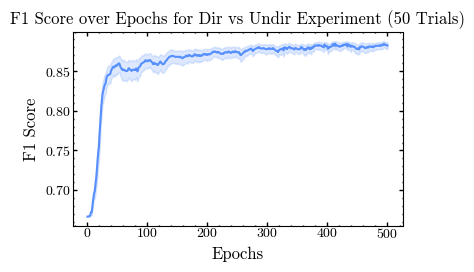

In [7]:
plot_metric_over_epochs("F1 Score", overall_history_dir_vs_undir)

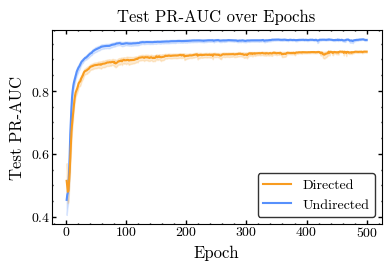

In [22]:
plot_hyperparameter("PR-AUC", "directed", dir_vs_undir_df, overall_history_dir_vs_undir)
plt.legend(handles=[
    mlines.Line2D([], [], color=Color.ORANGE.value, label="Directed"),
    mlines.Line2D([], [], color=Color.BLUE.value, label="Undirected"),
])
plt.savefig(
    PLOTS_DIR / "PR-AUC_directed_vs_undirected.png",
    dpi=300,
    format="png",
    bbox_inches="tight",
    transparent=True,
)

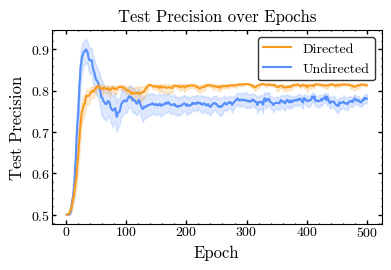

In [23]:
plot_hyperparameter("Precision", "directed", dir_vs_undir_df, overall_history_dir_vs_undir)
plt.legend(handles=[
    mlines.Line2D([], [], color=Color.ORANGE.value, label="Directed"),
    mlines.Line2D([], [], color=Color.BLUE.value, label="Undirected"),
])
plt.savefig(
    PLOTS_DIR / "Precision_directed_vs_undirected.png",
    dpi=300,
    format="png",
    bbox_inches="tight",
    transparent=True,
)

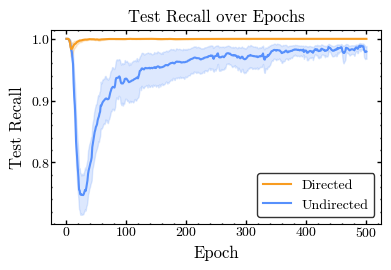

In [24]:
plot_hyperparameter("Recall", "directed", dir_vs_undir_df, overall_history_dir_vs_undir)
plt.legend(handles=[
    mlines.Line2D([], [], color=Color.ORANGE.value, label="Directed"),
    mlines.Line2D([], [], color=Color.BLUE.value, label="Undirected"),
])
plt.savefig(
    PLOTS_DIR / "Recall_directed_vs_undirected.png",
    dpi=300,
    format="png",
    bbox_inches="tight",
    transparent=True,
)

In [ ]:
def print_directed(metric: str = "ROC-AUC"):
    directed_roc = dir_vs_undir_df.filter(pl.col("directed"))[f"TEST: {metric}"]
    undirected_roc = dir_vs_undir_df.filter(~pl.col("directed"))[f"TEST: {metric}"]

    print(f"Directed has a {metric} of {directed_roc.mean():.3f}±{(directed_roc.std() * 3):.3f}")
    print(f"Undirected has a {metric} of {undirected_roc.mean():.3f}±{(undirected_roc.std() * 3):.3f}")

print_directed("PR")

Directed has a PR-AUC of 0.925±0.030
Undirected has a PR-AUC of 0.962±0.030


## GraphSAGE vs GCN

In [3]:
gsage_vs_gcn_df = experiment_service.get_experiment_runs_as_df(experiment_name="GraphSAGE vs GCN")
gsage_vs_gcn_df

run_id,duration (sec),system/gpu_0_memory_usage_megabytes,Loss,TEST: Accuracy,TEST: ROC-AUC,TEST: PR-AUC,TEST: Precision,TEST: Recall,TEST: F1 Score,TRAIN: Accuracy,TRAIN: ROC-AUC,TRAIN: PR-AUC,TRAIN: Precision,TRAIN: Recall,TRAIN: F1 Score,VAL: Accuracy,VAL: ROC-AUC,VAL: PR-AUC,VAL: Precision,VAL: Recall,VAL: F1 Score,epochs,hidden_dim,threshold,device,num_layers,homogeneous,directed,graphsage,agg_method
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,str,i64,bool,bool,bool,str
"""602893bfdcf14c608df743182c877c…",73.918,1083.6,0.604266,0.889332,0.952023,0.911858,0.818775,1.0,0.900359,0.819557,0.874826,0.788938,0.734815,1.0,0.847139,0.866612,0.936933,0.889618,0.789405,1.0,0.88231,500,24,0.5,"""cuda""",8,true,true,true,null
"""043a26aa23534e71a85b918ddc643d…",71.833,1098.6,0.602931,0.88342,0.958126,0.929045,0.810925,1.0,0.895592,0.823843,0.883834,0.789533,0.739474,1.0,0.850227,0.878988,0.940813,0.893838,0.805137,1.0,0.892051,500,24,0.5,"""cuda""",8,true,true,true,null
"""ebf9cac7fb404f7cac6ef19d2c917c…",71.441,821.0,0.605025,0.876684,0.957113,0.92258,0.802161,1.0,0.890222,0.802248,0.869274,0.773373,0.716587,1.0,0.834898,0.869637,0.943249,0.896177,0.793194,1.0,0.884672,500,24,0.5,"""cuda""",8,true,true,true,null
"""a72b86e110ff4c189f2ee9b2809e95…",71.334,1007.2,0.602459,0.891669,0.959377,0.930769,0.821921,1.0,0.902258,0.825057,0.877827,0.786734,0.740803,1.0,0.851105,0.867712,0.936724,0.890985,0.790779,1.0,0.883167,500,24,0.5,"""cuda""",8,true,true,true,null
"""d6aa1175534042a8952fde933e0f45…",70.967,1253.0,0.601769,0.88672,0.957416,0.928385,0.815288,1.0,0.898246,0.816402,0.875964,0.797414,0.731425,1.0,0.844882,0.880088,0.945604,0.901467,0.806566,1.0,0.892927,500,24,0.5,"""cuda""",8,true,true,true,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""191c2d1d36024d8b9133c3c372b46d…",74.436,1135.9,0.606025,0.875722,0.954637,0.921783,0.800925,1.0,0.88946,0.810336,0.875103,0.777212,0.724991,1.0,0.840574,0.875688,0.947267,0.900881,0.800881,1.0,0.889432,500,24,0.5,"""cuda""",8,true,true,true,null
"""e4f04524f08249e39e608dc822e882…",73.518,1065.2,0.602647,0.862936,0.932974,0.886213,0.784851,1.0,0.879458,0.814785,0.857775,0.759529,0.729698,1.0,0.843729,0.855061,0.923955,0.869671,0.775267,1.0,0.873409,500,24,0.5,"""cuda""",8,true,true,true,null
"""5d3d532957714d828eecd0432232f5…",75.868,1061.1,0.598728,0.890157,0.963348,0.936848,0.820027,0.999725,0.901004,0.815513,0.87748,0.777161,0.730474,1.0,0.844247,0.878438,0.94631,0.901085,0.804425,1.0,0.891614,500,24,0.5,"""cuda""",8,true,true,true,null


In [4]:
overall_history_gsage_vs_gcn = experiment_service.all_runs_history(experiment_name="GraphSAGE vs GCN")
overall_history_gsage_vs_gcn

Fetching Run Histories: 100%|██████████| 120/120 [00:58<00:00,  2.04run/s]


run_id,timestamp,step,metric,value
str,i64,i64,str,f64
"""602893bfdcf14c608df743182c877c…",1758766243599,0,"""system/gpu_0_memory_usage_mega…",840.3
"""602893bfdcf14c608df743182c877c…",1758766253621,1,"""system/gpu_0_memory_usage_mega…",1097.0
"""602893bfdcf14c608df743182c877c…",1758766263644,2,"""system/gpu_0_memory_usage_mega…",1097.3
"""602893bfdcf14c608df743182c877c…",1758766273666,3,"""system/gpu_0_memory_usage_mega…",1106.9
"""602893bfdcf14c608df743182c877c…",1758766283692,4,"""system/gpu_0_memory_usage_mega…",1079.2
…,…,…,…,…
"""ce57da0ebda4443c984cdf1c667f52…",1758720141353,496,"""VAL: F1 Score""",0.887262
"""ce57da0ebda4443c984cdf1c667f52…",1758720141487,497,"""VAL: F1 Score""",0.887262
"""ce57da0ebda4443c984cdf1c667f52…",1758720141621,498,"""VAL: F1 Score""",0.887046


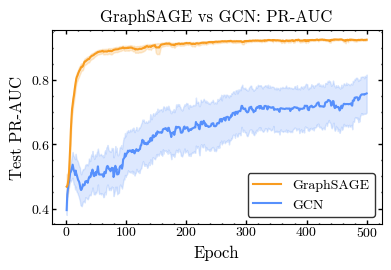

In [13]:
plot_hyperparameter("PR-AUC", "graphsage", gsage_vs_gcn_df, overall_history_gsage_vs_gcn)
plt.title("GraphSAGE vs GCN: PR-AUC")
plt.legend(handles=[
    mlines.Line2D([], [], color=Color.ORANGE.value, label="GraphSAGE"),
    mlines.Line2D([], [], color=Color.BLUE.value, label="GCN"),
])
plt.savefig(
    PLOTS_DIR / "PR-AUC_GraphSAGE_vs_GCN.png",
    dpi=300,
    format="png",
    bbox_inches="tight",
    transparent=True,
)

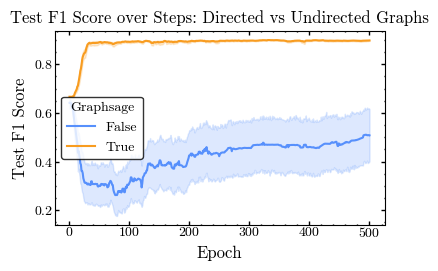

In [ ]:
plot_hyperparameter("F1 Score", "graphsage", gsage_vs_gcn_df, overall_history_gsage_vs_gcn)

In [ ]:

print(f"GraphSAGE has an average TEST: Precision of {gsage_vs_gcn_df.filter(pl.col('graphsage'))['TEST: Precision'].mean():.4f}±{(gsage_vs_gcn_df.filter(pl.col('graphsage'))['TEST: Precision'].std() * 3):.4f}")

GraphSAGE has an average TEST: Precision of 0.8151±0.0338


In [55]:

print(f"GCN has an average TEST: Precision of {gsage_vs_gcn_df.filter(~pl.col('graphsage'))['TEST: Precision'].mean():.4f}±{(gsage_vs_gcn_df.filter(~pl.col('graphsage'))['TEST: Precision'].std() * 3):.4f}")

GCN has an average TEST: Precision of 0.4710±1.1755


GraphSAGE has better F1 performance and a tighter variance than GCN.

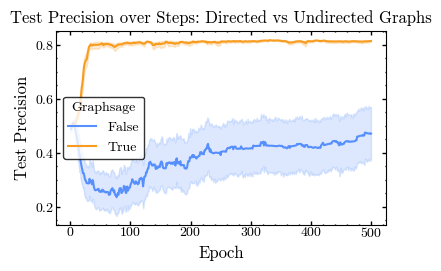

In [32]:
plot_hyperparameter("Precision", "graphsage", gsage_vs_gcn_df, overall_history_gsage_vs_gcn)

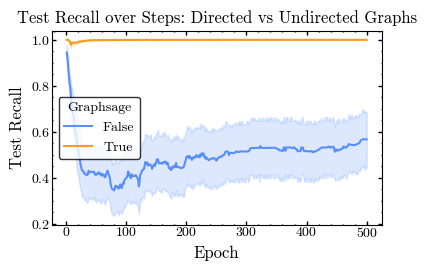

In [33]:
plot_hyperparameter("Recall", "graphsage", gsage_vs_gcn_df, overall_history_gsage_vs_gcn)

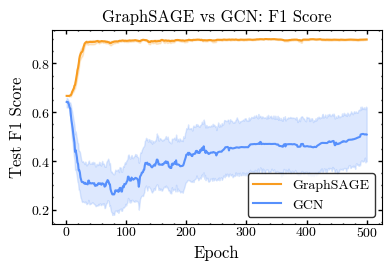

In [15]:
plot_hyperparameter("F1 Score", "graphsage", gsage_vs_gcn_df, overall_history_gsage_vs_gcn)
plt.title("GraphSAGE vs GCN: F1 Score")
plt.xlabel("Epoch")
plt.ylabel("Test F1 Score")
plt.legend(handles=[
    mlines.Line2D([], [], color=Color.ORANGE.value, label="GraphSAGE"),
    mlines.Line2D([], [], color=Color.BLUE.value, label="GCN"),
])
plt.savefig(
    PLOTS_DIR / "F1-Score_GraphSAGE_vs_GCN.png",
    dpi=300,
    format="png",
    bbox_inches="tight",
    transparent=True,
)

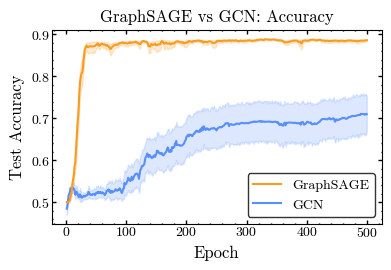

In [12]:
plot_hyperparameter("Accuracy", "graphsage", gsage_vs_gcn_df, overall_history_gsage_vs_gcn)
plt.title("GraphSAGE vs GCN: Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.legend(handles=[
    mlines.Line2D([], [], color=Color.ORANGE.value, label="GraphSAGE"),
    mlines.Line2D([], [], color=Color.BLUE.value, label="GCN"),
])
plt.savefig(
    PLOTS_DIR / "Accuracy_GraphSAGE_vs_GCN.png",
    dpi=300,
    format="png",
    bbox_inches="tight",
    transparent=True,
)

# plt.scatter(500, 0.710 + 0.048, color="red")  # GCN

In [17]:
import math


def print_metric(graphsage: bool, metric: str):
    metric_name = resolve_name(metric)

    if graphsage:
        data = gsage_vs_gcn_df.filter(pl.col("graphsage"))[metric_name]
        model_name = "GraphSAGE"
    else:
        data = gsage_vs_gcn_df.filter(~pl.col("graphsage"))[metric_name]
        model_name = "GCN"

    mean = data.mean()
    standard_error = data.std() / math.sqrt(len(data))


    print(f"{model_name} {metric_name}: {mean:.3f} ± {standard_error * 2:.3f}")

In [22]:
print_metric(False, "PR-AUC")

GCN TEST: PR-AUC: 0.758 ± 0.061


In [27]:
print_metric(True, "PR-AUC")

GraphSAGE TEST: PR-AUC: 0.925 ± 0.002


In [ ]:
gsage_vs_gcn_df.filter(~pl.col("graphsage"))["TEST: PR-AUC"].mean() 

0.7577049542220988

In [59]:
gsage_vs_gcn_df.filter(~pl.col("graphsage"))["TEST: PR-AUC"].std() * 2

0.46871787159319356

## Num Layers

In [21]:
num_layers_df = experiment_service.get_experiment_runs_as_df(experiment_name="Num Layers")
num_layers_df

run_id,duration (sec),system/gpu_0_memory_usage_megabytes,Loss,TEST: Accuracy,TEST: ROC-AUC,TEST: PR-AUC,TEST: Precision,TEST: Recall,TEST: F1 Score,TRAIN: Accuracy,TRAIN: ROC-AUC,TRAIN: PR-AUC,TRAIN: Precision,TRAIN: Recall,TRAIN: F1 Score,VAL: Accuracy,VAL: ROC-AUC,VAL: PR-AUC,VAL: Precision,VAL: Recall,VAL: F1 Score,epochs,hidden_dim,threshold,device,num_layers,homogeneous,directed,graphsage,agg_method
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,str,i64,bool,bool,bool,str
"""29bc0c5531b94c34b584c453228034…",293.378,2194.5,0.617603,0.752131,0.894193,0.912581,0.668566,1.0,0.801366,0.743206,0.824773,0.49574,0.660682,1.0,0.795675,0.749725,0.870799,0.89716,0.666422,1.0,0.799824,500,24,0.5,"""cuda""",64,true,true,true,null
"""dbec7fcc18d842389dac6f371fc214…",280.307,2173.6,0.612119,0.5,0.913515,0.854269,0.5,1.0,0.666667,0.5,0.833396,0.744252,0.5,1.0,0.666667,0.5,0.888781,0.81836,0.5,1.0,0.666667,500,24,0.5,"""cuda""",64,true,true,true,null
"""089564388c4f445a8feb3eb0c65981…",279.939,2172.0,0.616095,0.88782,0.889393,0.826916,0.816753,1.0,0.899135,0.819476,0.817799,0.728951,0.734728,1.0,0.847081,0.881738,0.880558,0.813578,0.808719,1.0,0.894245,500,24,0.5,"""cuda""",64,true,true,true,null
"""f78084e70a3341d986131416b42a4f…",279.813,2166.3,0.613104,0.893181,0.894301,0.912611,0.823969,1.0,0.90349,0.816322,0.817372,0.866137,0.731338,1.0,0.844824,0.878713,0.880988,0.903668,0.804781,1.0,0.891832,500,24,0.5,"""cuda""",64,true,true,true,null
"""6eda6dd16b6046db808ec0973b9ca2…",279.656,2175.9,0.610793,0.88782,0.885194,0.788815,0.816753,1.0,0.899135,0.822954,0.822653,0.735707,0.738502,1.0,0.849584,0.873762,0.87046,0.767782,0.798419,1.0,0.887912,500,24,0.5,"""cuda""",64,true,true,true,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""c81fd4b331084d9dad58c6997f4666…",47.275,1002.4,0.607914,0.881771,0.953429,0.913966,0.808761,1.0,0.894271,0.822549,0.876493,0.785673,0.738061,1.0,0.849292,0.879538,0.938241,0.88659,0.805851,1.0,0.892489,500,24,0.5,"""cuda""",2,true,true,true,null
"""67d0181d5d17429dad32dfb3d5dee1…",45.999,1010.0,0.601789,0.872835,0.948892,0.907335,0.797238,1.0,0.887181,0.80694,0.865992,0.762242,0.721438,1.0,0.83818,0.866887,0.940139,0.892917,0.789748,1.0,0.882524,500,24,0.5,"""cuda""",2,true,true,true,null
"""404aa59a0d6c403fafe040549ed86a…",46.378,1014.8,0.60443,0.889744,0.950499,0.912163,0.819329,1.0,0.900693,0.825057,0.87649,0.77906,0.740803,1.0,0.851105,0.870462,0.929767,0.868125,0.794233,1.0,0.885318,500,24,0.5,"""cuda""",2,true,true,true,null


In [20]:
overall_history_num_layers = experiment_service.all_runs_history(experiment_name="Num Layers")
overall_history_num_layers

Fetching Run Histories:   1%|          | 3/250 [00:01<02:28,  1.66run/s]


KeyboardInterrupt: 

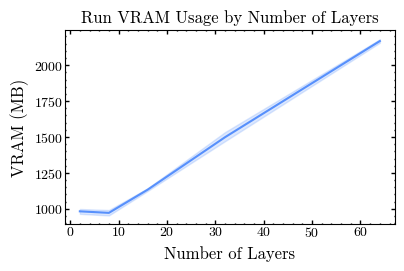

In [25]:
sns.lineplot(
    data=num_layers_df,
    x="num_layers",
    y="system/gpu_0_memory_usage_megabytes",
)
plt.xlabel("Number of Layers")
plt.ylabel("VRAM (MB)")
plt.title("Run VRAM Usage by Number of Layers")
plt.savefig(
    PLOTS_DIR / "VRAM_USAGE_Number_of_Layers.png",
    dpi=300,
    format="png",
    bbox_inches="tight",
)

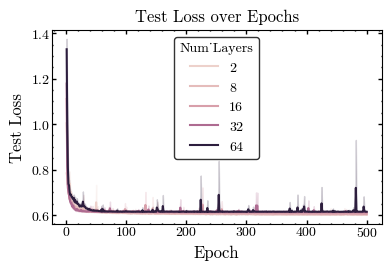

In [18]:
plot_hyperparameter("Loss", "num_layers", num_layers_df, overall_history_num_layers)

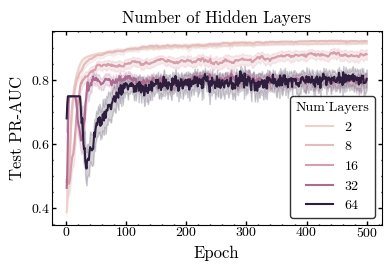

In [19]:
plot_hyperparameter("PR-AUC", "num_layers", num_layers_df, overall_history_num_layers)
plt.title("Number of Hidden Layers")
plt.savefig(
    PLOTS_DIR / "PR-AUC_Num_Layers.png",
    dpi=300,
    format="png",
    bbox_inches="tight",
    transparent=True,
)

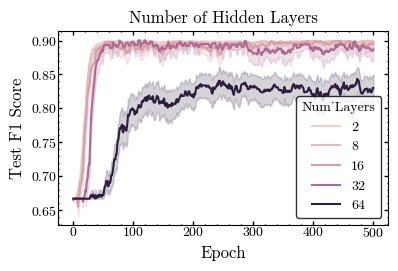

In [20]:
plot_hyperparameter("F1 Score", "num_layers", num_layers_df, overall_history_num_layers)
plt.title("Number of Hidden Layers")
plt.savefig(
    PLOTS_DIR / "F1-Score_Num_Layers.png",
    dpi=300,
    format="png",
    bbox_inches="tight",
    transparent=True,
)

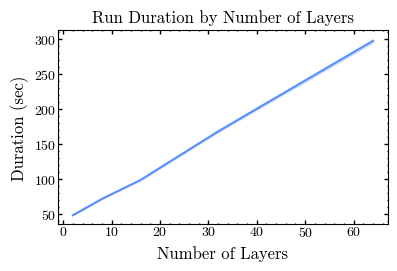

In [45]:
sns.lineplot(
    data=num_layers_df,
    x="num_layers",
    y="duration (sec)",
)
plt.xlabel("Number of Layers")
plt.ylabel("Duration (sec)")
plt.title("Run Duration by Number of Layers")
plt.savefig(
    PLOTS_DIR / "Duration_Num_Layers.png",
    dpi=300,
    format="png",
    bbox_inches="tight",
    transparent=True,
)   

In [38]:
def layer_metric(layer: int, metric: str):
    metric_name = resolve_name(metric)

    print(f"Model with {layer} layers has a {metric_name} of {num_layers_df.filter(pl.col('num_layers') == layer)[metric_name].mean():.2f}±{(num_layers_df.filter(pl.col('num_layers') == layer)[metric_name].std() * 3):.2f}")

layer_metric(2, "Accuracy")

Model with 2 layers has a TEST: Accuracy of 0.89±0.02


### General Insights

The model was trained using layers 2, 8, 16, and 32 with a learning rate of `0.1`. However, when tried with 64, the model becomes numerically unstable (NaNs in the output). So we trained it with a learning rate of `0.01`, to keep it steady and slower.

The result being is that it is slower to converge and had lower performance compared to layers 2-32.

### PR-AUC

We can see that the more the layers, the lower the performance.

### F1 Score

Has a higher variance with the higher number of layers.


### Training Time

Training time increases quadratically with the number of layers.


## Classification Threshold

In [12]:
threshold_df = experiment_service.get_experiment_runs_as_df(experiment_name="F1 Score threshold")
threshold_df

run_id,duration (sec),Loss,TEST: Accuracy,TEST: ROC-AUC,TEST: PR-AUC,TEST: Precision,TEST: Recall,TEST: F1 Score,TRAIN: Accuracy,TRAIN: ROC-AUC,TRAIN: PR-AUC,TRAIN: Precision,TRAIN: Recall,TRAIN: F1 Score,VAL: Accuracy,VAL: ROC-AUC,VAL: PR-AUC,VAL: Precision,VAL: Recall,VAL: F1 Score,epochs,hidden_dim,threshold,device,num_layers,homogeneous,directed,graphsage,agg_method
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,str,i64,bool,bool,bool,str
"""cd3753ac806b45938226e8ebbd9eff…",90.31,0.562567,0.905485,0.974484,0.96876,0.934965,0.871597,0.90217,0.83363,0.908962,0.863419,0.802021,0.885959,0.841903,0.890539,0.964816,0.950661,0.908046,0.869087,0.888139,500,24,0.55,"""cuda""",8,true,false,true,"""mean"""
"""c573b8fa6bb74a11bd1718b039a2bc…",88.093,0.565313,0.911672,0.97133,0.964237,0.927115,0.893594,0.910046,0.833064,0.905225,0.852831,0.792555,0.902297,0.843873,0.897277,0.961938,0.952393,0.900471,0.893289,0.896866,500,24,0.55,"""cuda""",8,true,false,true,"""mean"""
"""66bc93aea74948cba546bc1d839b06…",87.452,0.574709,0.850426,0.973104,0.966508,0.955341,0.735221,0.830951,0.798771,0.900051,0.855517,0.831241,0.749757,0.788399,0.842547,0.957462,0.939487,0.92292,0.747525,0.826014,500,24,0.55,"""cuda""",8,true,false,true,"""mean"""
"""4c965a8af0f247209a8e13e3343d50…",71.92,0.600267,0.5,0.957777,0.920056,0.5,1.0,0.666667,0.5,0.872783,0.776985,0.5,1.0,0.666667,0.5,0.95181,0.916441,0.5,1.0,0.666667,500,24,0.49,"""cuda""",8,true,true,true,"""mean"""
"""036f415268ad419e8a739d1b72152f…",71.617,0.603528,0.5,0.95769,0.926822,0.5,1.0,0.666667,0.5,0.871098,0.776882,0.5,1.0,0.666667,0.5,0.935239,0.876149,0.5,1.0,0.666667,500,24,0.49,"""cuda""",8,true,true,true,"""mean"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""05efecec63fd4af78634c449699210…",75.574,0.605462,0.5,0.956682,0.916547,0.5,1.0,0.666667,0.5,0.881342,0.787726,0.5,1.0,0.666667,0.5,0.947782,0.90626,0.5,1.0,0.666667,500,24,0.1,"""cuda""",8,true,true,true,null
"""b7e1177add914fb0beef1f8811d86c…",74.764,0.604094,0.5,0.953227,0.918175,0.5,1.0,0.666667,0.5,0.880722,0.791411,0.5,1.0,0.666667,0.5,0.937847,0.890282,0.5,1.0,0.666667,500,24,0.1,"""cuda""",8,true,true,true,null
"""07c7b10bf8af42b2978e301b4dd287…",75.035,0.602904,0.5,0.956672,0.919734,0.5,1.0,0.666667,0.5,0.872589,0.77915,0.5,1.0,0.666667,0.5,0.952366,0.916804,0.5,1.0,0.666667,500,24,0.1,"""cuda""",8,true,true,true,null


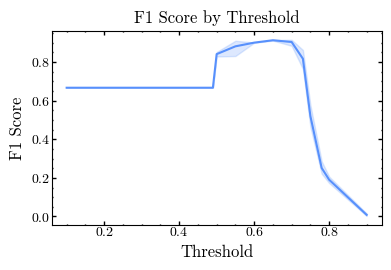

In [13]:
sns.lineplot(
    data=threshold_df,
    x="threshold",
    y="TEST: F1 Score",
)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score by Threshold")
plt.savefig(
    PLOTS_DIR / "F1_Score_Threshold.png",
    dpi=300,
    format="png",
    bbox_inches="tight",
    transparent=True,
)

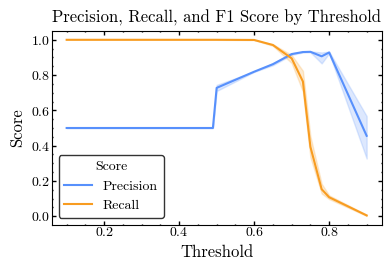

In [14]:
sns.lineplot(
    data=threshold_df,
    x="threshold",
    y="TEST: Precision",
    label="Precision",
)

sns.lineplot(
    data=threshold_df,
    x="threshold",
    y="TEST: Recall",
    label="Recall",
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 Score by Threshold")
plt.legend(title="Score")
plt.savefig(
    PLOTS_DIR / "Precision_Recall_F1_Threshold.png",
    dpi=300,
    format="png",
    bbox_inches="tight",
    transparent=True,
)

### Undirected Classification Threshold

In [6]:
undir_threshold_df = experiment_service.get_experiment_runs_as_df(experiment_name="F1 Score threshold (Undirected)")
undir_threshold_df

run_id,duration (sec),Loss,TEST: Accuracy,TEST: ROC-AUC,TEST: PR-AUC,TEST: Precision,TEST: Recall,TEST: F1 Score,TRAIN: Accuracy,TRAIN: ROC-AUC,TRAIN: PR-AUC,TRAIN: Precision,TRAIN: Recall,TRAIN: F1 Score,VAL: Accuracy,VAL: ROC-AUC,VAL: PR-AUC,VAL: Precision,VAL: Recall,VAL: F1 Score,epochs,hidden_dim,threshold,device,num_layers,homogeneous,directed,graphsage,agg_method
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,str,i64,bool,bool,bool,str
"""199d35e59acf4c018722a62f0857be…",86.397,0.561179,0.5,0.972848,0.964307,0.5,1.0,0.666667,0.5,0.911226,0.86015,0.5,1.0,0.666667,0.5,0.961705,0.944442,0.5,1.0,0.666667,500,24,0.3,"""cuda""",8,true,false,true,"""mean"""
"""61cbd63dcdd04fa2aa0ed5a8cbe078…",87.053,0.562924,0.5,0.947149,0.951551,0.5,1.0,0.666667,0.5,0.892918,0.851061,0.5,1.0,0.666667,0.5,0.939797,0.940918,0.5,1.0,0.666667,500,24,0.3,"""cuda""",8,true,false,true,"""mean"""
"""e3e7102e52184b39836396a77a3494…",85.491,0.559921,0.5,0.951554,0.954682,0.5,1.0,0.666667,0.5,0.895902,0.856548,0.5,1.0,0.666667,0.5,0.945555,0.941238,0.5,1.0,0.666667,500,24,0.3,"""cuda""",8,true,false,true,"""mean"""
"""1fbf62f61e4943f0bb254423319478…",84.704,0.564934,0.5,0.969828,0.96217,0.5,1.0,0.666667,0.5,0.911212,0.858701,0.5,1.0,0.666667,0.5,0.957062,0.937146,0.5,1.0,0.666667,500,24,0.3,"""cuda""",8,true,false,true,"""mean"""
"""f681c98774f2465bbe774652293c07…",86.141,0.563909,0.5,0.968394,0.962895,0.5,1.0,0.666667,0.5,0.910121,0.868061,0.5,1.0,0.666667,0.5,0.958434,0.940918,0.5,1.0,0.666667,500,24,0.3,"""cuda""",8,true,false,true,"""mean"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""63261021121e47d3878e63b3ba4546…",82.716,0.572595,0.796673,0.956422,0.955212,0.721379,0.966731,0.826225,0.759544,0.902339,0.86257,0.682309,0.971368,0.801575,0.787404,0.942523,0.937856,0.712831,0.962596,0.819097,500,24,0.5,"""cuda""",8,true,false,true,"""mean"""
"""1476b18f2d5346d7a742cc0a4cc347…",82.78,0.562359,0.822862,0.954793,0.954957,0.751257,0.965356,0.844955,0.755581,0.899947,0.858419,0.678773,0.970398,0.798802,0.813394,0.947097,0.938837,0.73914,0.968647,0.838472,500,24,0.5,"""cuda""",8,true,false,true,"""mean"""
"""d1c10881def34bb08e3d42a45e0e01…",83.327,0.565207,0.799973,0.972609,0.96309,0.71451,0.999175,0.8332,0.723674,0.908264,0.857545,0.6443,0.998706,0.783279,0.784516,0.964271,0.951763,0.699134,0.9989,0.822557,500,24,0.5,"""cuda""",8,true,false,true,"""mean"""


In [7]:
overall_history_undir_threshold = experiment_service.all_runs_history(experiment_name="F1 Score threshold (Undirected)")
overall_history_undir_threshold

Fetching Run Histories: 100%|██████████| 481/481 [03:43<00:00,  2.15run/s]


run_id,timestamp,step,metric,value
str,i64,i64,str,f64
"""199d35e59acf4c018722a62f0857be…",1759283328470,1,"""Loss""",0.830678
"""199d35e59acf4c018722a62f0857be…",1759283328633,2,"""Loss""",0.842401
"""199d35e59acf4c018722a62f0857be…",1759283328790,3,"""Loss""",0.758529
"""199d35e59acf4c018722a62f0857be…",1759283329009,4,"""Loss""",0.726633
"""199d35e59acf4c018722a62f0857be…",1759283329171,5,"""Loss""",0.698242
…,…,…,…,…
"""0731418ce9784dc29c5c92d44fa450…",1759188551115,496,"""VAL: F1 Score""",0.851443
"""0731418ce9784dc29c5c92d44fa450…",1759188551266,497,"""VAL: F1 Score""",0.845589
"""0731418ce9784dc29c5c92d44fa450…",1759188551421,498,"""VAL: F1 Score""",0.840009


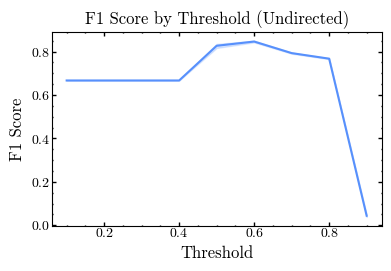

In [15]:
sns.lineplot(
    data=undir_threshold_df,
    x="threshold",
    y="TEST: F1 Score",
)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score by Threshold (Undirected)")
plt.savefig(
    PLOTS_DIR / "F1_Score_Threshold_Undirected.png",
    dpi=300,
    format="png",
    bbox_inches="tight",
    transparent=True,
)

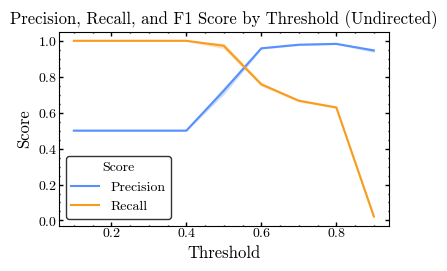

In [10]:
sns.lineplot(
    data=undir_threshold_df,
    x="threshold",
    y="TEST: Precision",
    label="Precision",
)

sns.lineplot(
    data=undir_threshold_df,
    x="threshold",
    y="TEST: Recall",
    label="Recall",
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 Score by Threshold (Undirected)")
plt.legend(title="Score")
plt.savefig(
    PLOTS_DIR / "Precision_Recall_F1_Threshold_Undirected.png",
    dpi=300,
    format="png",
    bbox_inches="tight",
    transparent=True,
)

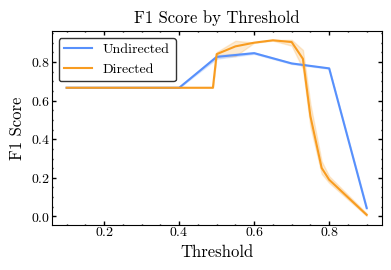

In [ ]:
sns.lineplot(
    data=undir_threshold_df,
    x="threshold",
    y="TEST: F1 Score",
    label="Undirected",
)
sns.lineplot(
    data=threshold_df,
    x="threshold",
    y="TEST: F1 Score",
    label="Directed",
)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score by Threshold")
plt.savefig(
    PLOTS_DIR / "F1_Score_Threshold_dir_vs_undir.png",
    dpi=300,
    format="png",
    bbox_inches="tight",
    transparent=True,
)

## Aggregation Method

In [4]:
agg_method_def = experiment_service.get_experiment_runs_as_df(experiment_name="GraphSAGE Aggregation")
agg_method_def

run_id,duration (sec),Loss,TEST: Accuracy,TEST: ROC-AUC,TEST: PR-AUC,TEST: Precision,TEST: Recall,TEST: F1 Score,TRAIN: Accuracy,TRAIN: ROC-AUC,TRAIN: PR-AUC,TRAIN: Precision,TRAIN: Recall,TRAIN: F1 Score,VAL: Accuracy,VAL: ROC-AUC,VAL: PR-AUC,VAL: Precision,VAL: Recall,VAL: F1 Score,epochs,hidden_dim,threshold,device,num_layers,homogeneous,directed,graphsage,agg_method
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,str,i64,bool,bool,bool,str
"""c6f05bd43235420fa5fb06e2794744…",172.672,0.599121,0.837366,0.95893,0.926185,0.754564,1.0,0.860116,0.77944,0.877704,0.788082,0.693905,1.0,0.819296,0.827283,0.949378,0.917152,0.743254,1.0,0.85272,500,24,0.5,"""cpu""",8,true,true,true,"""median"""
"""b87776d8b56541fe812bcf39c8bf3d…",78.407,0.600519,0.837641,0.958811,0.926366,0.754878,1.0,0.860319,0.779036,0.879888,0.781577,0.693516,1.0,0.819025,0.827283,0.943241,0.901887,0.743254,1.0,0.85272,500,24,0.5,"""cuda""",8,true,true,true,"""median"""
"""bc5539d992a64976814e7cc67b9572…",78.109,0.599997,0.840803,0.956582,0.923309,0.758498,1.0,0.862666,0.774507,0.875037,0.772696,0.689186,1.0,0.815998,0.831133,0.946797,0.900949,0.747533,1.0,0.855529,500,24,0.5,"""cuda""",8,true,true,true,"""median"""
"""935fde61b91244fc805f67654b0097…",74.728,0.606416,0.793511,0.957531,0.923008,0.707725,1.0,0.828851,0.749434,0.872753,0.781526,0.666164,1.0,0.799638,0.788229,0.936588,0.879832,0.702473,1.0,0.825238,500,24,0.5,"""cuda""",8,true,true,true,"""max"""
"""4ea971bcbc614edcb56ebf7a8d4eb9…",74.833,0.601621,0.835304,0.95263,0.913364,0.752223,1.0,0.858593,0.788742,0.884864,0.796688,0.702979,1.0,0.825588,0.837184,0.944267,0.892766,0.754357,1.0,0.859981,500,24,0.5,"""cuda""",8,true,true,true,"""max"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ced26a66769d4141b8cedee40cdb42…",74.421,0.595216,0.831454,0.959541,0.927592,0.747892,1.0,0.855765,0.768117,0.878503,0.780738,0.683169,1.0,0.811765,0.819307,0.951778,0.91174,0.734545,1.0,0.84696,500,24,0.5,"""cuda""",8,true,true,true,"""sum"""
"""f2d45f8464d64376aebc826b86dc82…",73.905,0.600361,0.739483,0.958052,0.927803,0.657448,1.0,0.793325,0.708104,0.874303,0.775506,0.631396,1.0,0.774056,0.729923,0.942022,0.895328,0.649286,1.0,0.787354,500,24,0.5,"""cuda""",8,true,true,true,"""sum"""
"""8e36e67162064786be8365f0173d20…",73.065,0.600266,0.84369,0.959768,0.925931,0.761835,1.0,0.86482,0.779926,0.877571,0.782417,0.694373,1.0,0.819622,0.826183,0.940921,0.897369,0.742041,1.0,0.851921,500,24,0.5,"""cuda""",8,true,true,true,"""sum"""


In [5]:
overall_history_agg_method = experiment_service.all_runs_history(experiment_name="GraphSAGE Aggregation")
overall_history_agg_method

Fetching Run Histories: 100%|██████████| 153/153 [01:10<00:00,  2.16run/s]


run_id,timestamp,step,metric,value
str,i64,i64,str,f64
"""c6f05bd43235420fa5fb06e2794744…",1759115139965,1,"""Loss""",0.909293
"""c6f05bd43235420fa5fb06e2794744…",1759115140284,2,"""Loss""",0.741089
"""c6f05bd43235420fa5fb06e2794744…",1759115140605,3,"""Loss""",0.731053
"""c6f05bd43235420fa5fb06e2794744…",1759115140914,4,"""Loss""",0.753391
"""c6f05bd43235420fa5fb06e2794744…",1759115141219,5,"""Loss""",0.694033
…,…,…,…,…
"""1e77014652f7407b9c46a258acca56…",1759100305004,496,"""VAL: F1 Score""",0.865508
"""1e77014652f7407b9c46a258acca56…",1759100305129,497,"""VAL: F1 Score""",0.861816
"""1e77014652f7407b9c46a258acca56…",1759100305253,498,"""VAL: F1 Score""",0.859981


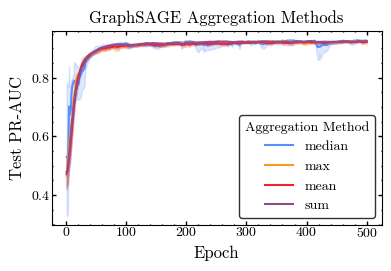

In [10]:
plot_hyperparameter("PR-AUC", "agg_method", agg_method_def, overall_history_agg_method)
plt.title("GraphSAGE Aggregation Methods")
plt.legend(title="Aggregation Method")
plt.savefig(
    PLOTS_DIR / "PR-AUC_GraphSAGE_Aggregation_Methods.png",
    dpi=300,
    format="png",
    bbox_inches="tight",
    transparent=True,
)

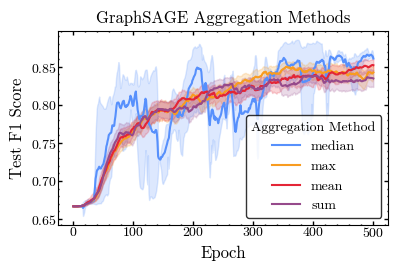

In [11]:
plot_hyperparameter("F1 Score", "agg_method", agg_method_def, overall_history_agg_method)
plt.title("GraphSAGE Aggregation Methods")
plt.legend(title="Aggregation Method")
plt.savefig(
    PLOTS_DIR / "F1-Score_GraphSAGE_Aggregation_Methods.png",
    dpi=300,
    format="png",
    bbox_inches="tight",
    transparent=True,
)

# finetuned data

In [3]:
finetuned_data_df = experiment_service.get_experiment_runs_as_df(experiment_name="Finetuned Test")
finetuned_data_df

run_id,duration (sec),system/gpu_0_memory_usage_megabytes,Loss,TEST: Accuracy,TEST: ROC-AUC,TEST: PR-AUC,TEST: Precision,TEST: Recall,TEST: F1 Score,TRAIN: Accuracy,TRAIN: ROC-AUC,TRAIN: PR-AUC,TRAIN: Precision,TRAIN: Recall,TRAIN: F1 Score,VAL: Accuracy,VAL: ROC-AUC,VAL: PR-AUC,VAL: Precision,VAL: Recall,VAL: F1 Score,epochs,hidden_dim,threshold,device,num_layers,homogeneous,directed,graphsage,agg_method
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,str,i64,bool,bool,bool,str
"""82e7510ad69f42d2964c91dde99393…",52.164,1632.4,0.562551,0.886032,0.916896,0.869635,0.820109,0.989002,0.896672,0.824167,0.849506,0.780233,0.743559,0.989647,0.849133,0.869637,0.907862,0.854822,0.797609,0.990649,0.88371,500,8,0.7,"""cuda""",2,true,true,true,"""mean"""
"""176f46b3393e44fab46948f0f11fa6…",51.481,1538.9,0.557571,0.905829,0.935175,0.894043,0.846642,0.991202,0.913236,0.833873,0.856285,0.771746,0.755193,0.98803,0.856062,0.89549,0.922101,0.873495,0.833179,0.988999,0.904427,500,8,0.7,"""cuda""",2,true,true,true,"""mean"""
"""db0442724597417aac658398e9d766…",52.791,1533.1,0.55683,0.91394,0.937415,0.900782,0.853819,0.9989,0.920679,0.840828,0.850808,0.767012,0.758845,0.999191,0.862589,0.893839,0.921904,0.867442,0.825455,0.9989,0.903932,500,8,0.7,"""cuda""",2,true,true,true,"""mean"""
"""679a6bf76195449a866bb6b05f3a81…",51.086,1541.3,0.55016,0.929337,0.963118,0.933701,0.889499,0.980478,0.932775,0.8621,0.881785,0.791142,0.794811,0.976221,0.876225,0.912266,0.94557,0.907694,0.863658,0.979098,0.917762,500,8,0.7,"""cuda""",2,true,true,true,"""mean"""
"""b184455fedd74c3fb9df04191b9807…",51.674,1537.0,0.557182,0.911603,0.936562,0.893769,0.851244,0.997525,0.918597,0.846652,0.858857,0.764079,0.767274,0.995147,0.866479,0.89714,0.914655,0.854137,0.830586,0.9978,0.906547,500,8,0.7,"""cuda""",2,true,true,true,"""mean"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""08d11ea745b34b37bdb5bff99244d3…",49.994,1625.6,0.556571,0.895381,0.92976,0.889135,0.832255,0.990377,0.904457,0.825946,0.850738,0.756728,0.745732,0.989162,0.850369,0.876788,0.914576,0.86492,0.8069,0.990649,0.889383,500,8,0.7,"""cuda""",2,true,true,true,"""mean"""
"""fd2034355d9347d9a8796e6110336a…",50.654,1629.3,0.561957,0.907616,0.939067,0.901928,0.844367,0.99945,0.915387,0.835733,0.853113,0.762193,0.753017,0.999191,0.858811,0.884213,0.915538,0.867032,0.812249,0.99945,0.896178,500,8,0.7,"""cuda""",2,true,true,true,"""mean"""
"""c145687b1c66489195d81c5bd99eeb…",51.681,1638.1,0.557909,0.917102,0.941885,0.904734,0.858798,0.99835,0.923331,0.847541,0.863832,0.791121,0.767393,0.997412,0.867412,0.893564,0.918082,0.867371,0.825968,0.99725,0.903563,500,8,0.7,"""cuda""",2,true,true,true,"""mean"""


In [17]:
import numpy as np

metric = "Recall"
error = finetuned_data_df[f"TEST: {metric}"].std() / np.sqrt(len(finetuned_data_df))

mean = finetuned_data_df[f"TEST: {metric}"].mean()

print(f"Finetuned Model {metric}: {mean:.3f} ± {error * 2:.3f}")

Finetuned Model Recall: 0.994 ± 0.002


In [4]:
all_runs_finetuned = experiment_service.all_runs_history(experiment_name="Finetuned Test")
all_runs_finetuned

Fetching Run Histories: 100%|██████████| 50/50 [00:23<00:00,  2.12run/s]


run_id,timestamp,step,metric,value
str,i64,i64,str,f64
"""82e7510ad69f42d2964c91dde99393…",1764066851345,0,"""system/gpu_0_memory_usage_mega…",1501.2
"""82e7510ad69f42d2964c91dde99393…",1764066861371,1,"""system/gpu_0_memory_usage_mega…",1611.1
"""82e7510ad69f42d2964c91dde99393…",1764066871395,2,"""system/gpu_0_memory_usage_mega…",1606.9
"""82e7510ad69f42d2964c91dde99393…",1764066881421,3,"""system/gpu_0_memory_usage_mega…",1609.8
"""82e7510ad69f42d2964c91dde99393…",1764066891448,4,"""system/gpu_0_memory_usage_mega…",1632.4
…,…,…,…,…
"""ed6047f2789542fc8e578d93af3329…",1764063908372,496,"""VAL: F1 Score""",0.91267
"""ed6047f2789542fc8e578d93af3329…",1764063908465,497,"""VAL: F1 Score""",0.912945
"""ed6047f2789542fc8e578d93af3329…",1764063908558,498,"""VAL: F1 Score""",0.912945
